In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [8]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout
print("run")

run


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
print("wow")

wow


In [13]:
train_ds = keras.utils.image_dataset_from_directory(
    '/kaggle/input/datasets/sunilthite/cat-or-dog-image-classification/Train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    '/kaggle/input/datasets/sunilthite/cat-or-dog-image-classification/Test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

print("first")

Found 23650 files belonging to 2 classes.


I0000 00:00:1791081773.082074      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791081773.085471      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3863 files belonging to 2 classes.
first


In [14]:
# Normalize: 0-255 -> 0-1 (for better results)
def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)
print("wlcm")

wlcm


In [34]:
# Creating cnn model :

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [35]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, epochs=10, validation_data = validation_ds)

Epoch 1/10


2026-10-04 03:13:06.763368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 03:13:07.074839: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 03:13:07.220808: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[32,32,127,127]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,125,125]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earl

739/740 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5470 - loss: 2.4386

2026-10-04 03:15:06.639146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-04 03:15:06.921783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


740/740 ━━━━━━━━━━━━━━━━━━━━ 135s 166ms/step - accuracy: 0.5469 - loss: 1.3435 - val_accuracy: 0.5302 - val_loss: 0.6764
Epoch 2/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 86ms/step - accuracy: 0.6368 - loss: 0.6261 - val_accuracy: 0.6536 - val_loss: 0.6975
Epoch 3/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 63s 86ms/step - accuracy: 0.7074 - loss: 0.5512 - val_accuracy: 0.7075 - val_loss: 0.5331
Epoch 4/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.7524 - loss: 0.4752 - val_accuracy: 0.7657 - val_loss: 0.5407
Epoch 5/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.7882 - loss: 0.4222 - val_accuracy: 0.7657 - val_loss: 0.4434
Epoch 6/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 86ms/step - accuracy: 0.8102 - loss: 0.3658 - val_accuracy: 0.8118 - val_loss: 0.3939
Epoch 7/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.8461 - loss: 0.3033 - val_accuracy: 0.8537 - val_loss: 0.3259
Epoch 8/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.8807 - loss: 0.2488 - val_accur

In [17]:
# model.save('/kaggle/working/cat_dog_model.keras')

In [21]:
# import os
# path = "/kaggle/input/models/ayushpant2006/cat-dog-model/keras/default/1"
# print(os.listdir(path))

['cat_dog_model (1).keras']


In [26]:
# from tensorflow import keras
# model = keras.models.load_model(
#     "/kaggle/input/models/ayushpant2006/cat-dog-model/keras/default/1/cat_dog_model (1).keras"
# )
# print("stored")

stored


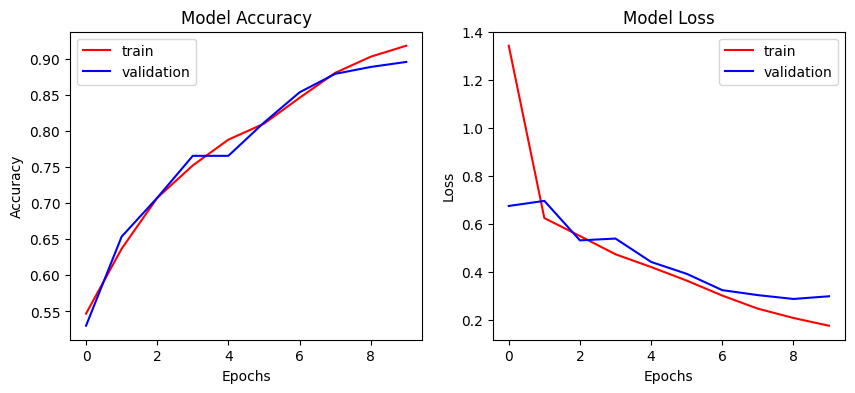

In [36]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Confusion Matrix:
[[1724  220]
 [ 182 1737]]


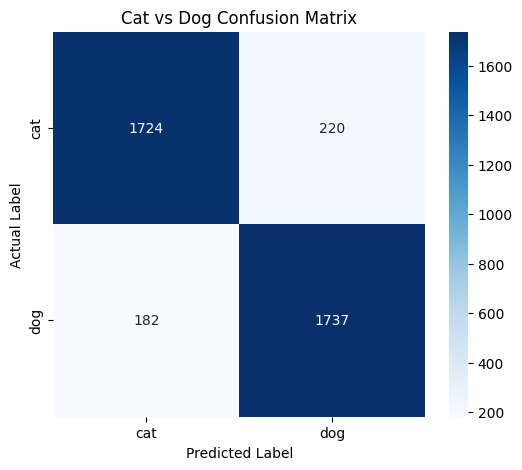


Classification Report:


AttributeError: '_MapDataset' object has no attribute 'class_names'

In [37]:
# Get actual labels and predictions
y_true = []
y_pred = []

for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)

    # Convert probability to 0 or 1
    predictions = (predictions >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['cat', 'dog'],
    yticklabels=['cat', 'dog']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Cat vs Dog Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names
))

### TO predict from image in your pc

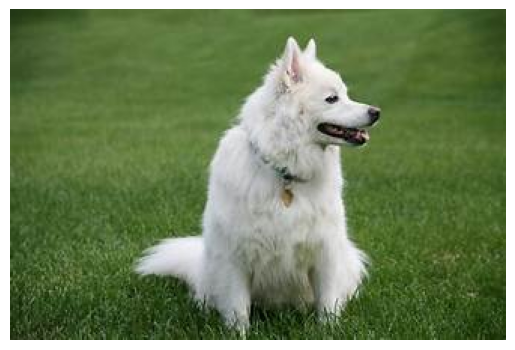

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw Prediction Value: 0.9988967180252075
Prediction: It's a DOG!


In [39]:
import cv2 
import os
image_path = '/kaggle/input/datasets/ayushpant2006/imagedataset/OIP.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")

### Function to directly predict by image address

In [44]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_from_url(url):

    # Download image into memory
    response = requests.get(url)
    image_array = np.frombuffer(response.content, np.uint8)

    # Decode image
    test_img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if test_img is None:
        print("Could not load image. Check the URL.")
        return

    # BGR → RGB
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

    # Show image
    plt.figure(figsize=(5, 5))
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Resize
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Normalize
    test_input = test_img_resized.astype(np.float32) / 255.0

    # Add batch dimension
    test_input = np.expand_dims(test_input, axis=0)

    # Prediction
    prediction = model.predict(test_input, verbose=0)
    probability = prediction[0][0]

    print("Raw Prediction:", probability)

    if probability < 0.5:
        print("Prediction: CAT 🐱")
    else:
        print("Prediction: DOG 🐶")

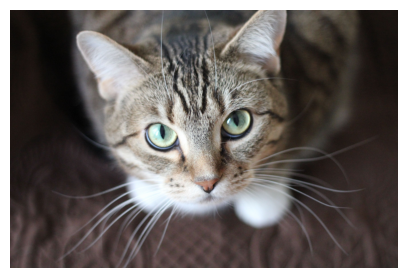

Raw Prediction: 1.4168733e-13
Prediction: CAT 🐱


In [47]:
predict_from_url("https://images.pexels.com/photos/20787/pexels-photo.jpg?cs=srgb&dl=animal-cat-adorable-20787.jpg&fm=jpg")